## Homework 8  

Name: Acamaro

Comments for grader: I worked with Connor Hunt so code can be slightly similar to his.


## 1. Electronic capacitor
Consider the following simple model of an electronic capacitor,
consisting of two flat metal plates enclosed in a square metal box:

![ch9_exercise9.3.PNG](attachment:ch9_exercise9.3.PNG)

For simplicity let us model the system in two dimensions.  

**a)** Using the **Jacobi method**, write a program to calculate the electrostatic
potential in the box on a grid of $100\times100$ points, where the walls of
the box are at voltage zero and the two plates (which are of negligible
thickness) are at voltages $\pm1\,$V as shown.  Have your program calculate
the value of the potential at each grid point to a precision of
$10^{-6}\,$volts and then make a density plot of the result. Include a colorbar that shows the scale.

Hint: Notice that the capacitor plates are at fixed *voltage*, not
fixed charge, so this problem differs from examples we did in class.  In effect, the capacitor plates are part of the boundary
condition in this case: they behave the same way as the walls of the box,
with potentials that are fixed at a certain value and cannot change.

In [4]:
#Type your code here
import numpy as np
import matplotlib.pyplot as plt

#Grid Parameters
N = 100
epsilon = 1e-6

# Initialize Potential Array
V_array = np.zeros((100,100))
# Start Initial Conditions!
V_array[20:80][20] = 1
V_array[20:80][40] = -1




[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


Solution converged in 2817 iterations with Jacobi method.


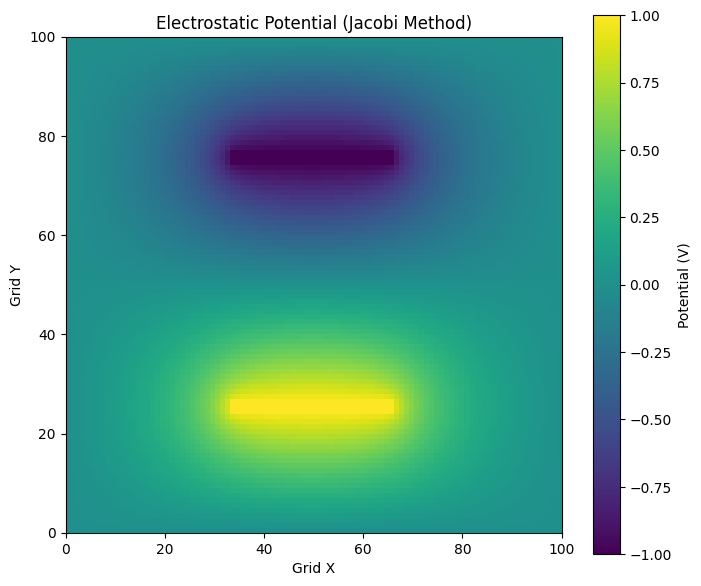

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define grid parameters
N = 100  # Grid size
epsilon = 1e-6 # Convergence target in volts

# Initialize potential array with zeros
V = np.zeros([N, N], float)

# Define fixed boundary conditions
# Box walls are at 0V (already handled by initializing V to zeros)

# Capacitor plate dimensions and positions
plate_width_start = N // 3
plate_width_end = 2 * N // 3
top_plate_row_center = N // 4
bottom_plate_row_center = 3 * N // 4
plate_thickness = 1 # Number of rows for plate thickness (e.g., 1 for single row, 3 for center + 1 above/below)

# Set capacitor plate voltages
# Top plate (+1V)
V[top_plate_row_center - plate_thickness:top_plate_row_center + plate_thickness + 1, plate_width_start:plate_width_end] = 1.0
# Bottom plate (-1V)
V[bottom_plate_row_center - plate_thickness:bottom_plate_row_center + plate_thickness + 1, plate_width_start:plate_width_end] = -1.0

# Create a mask for fixed points (boundary and capacitor plates)
# These points will not be updated during iteration
fixed_points = np.zeros([N, N], bool)
fixed_points[0, :] = True  # Top wall
fixed_points[N - 1, :] = True  # Bottom wall
fixed_points[:, 0] = True  # Left wall
fixed_points[:, N - 1] = True  # Right wall
fixed_points[top_plate_row_center - plate_thickness:top_plate_row_center + plate_thickness + 1, plate_width_start:plate_width_end] = True
fixed_points[bottom_plate_row_center - plate_thickness:bottom_plate_row_center + plate_thickness + 1, plate_width_start:plate_width_end] = True

# Jacobi iteration
converged = False
it = 0
max_iterations = 100000 # Safety break for very long computations

while not converged and it < max_iterations:
    it += 1
    V_new = np.copy(V) # Create a copy of V to store new values for Jacobi
    converged = True

    for j in range(1, N - 1):  # Rows
        for i in range(1, N - 1):  # Columns
            if not fixed_points[j, i]: # Only update non-fixed points
                # Jacobi update rule: use values from the previous iteration (V)
                V_new[j, i] = 0.25 * (V[j, i + 1] + V[j, i - 1] + V[j + 1, i] + V[j - 1, i])
                if abs(V_new[j, i] - V[j, i]) > epsilon:
                    converged = False

    V = np.copy(V_new) # Update V with the new values after all points are calculated

print(f"Solution converged in {it} iterations with Jacobi method.")

# Plotting the result
plt.figure(figsize=(8, 7))
plt.imshow(V, origin='lower', cmap='viridis', extent=[0, N, 0, N])
plt.colorbar(label='Potential (V)')
plt.title('Electrostatic Potential (Jacobi Method)')
plt.xlabel('Grid X')
plt.ylabel('Grid Y')
plt.show()


Solution converged in 91 iterations


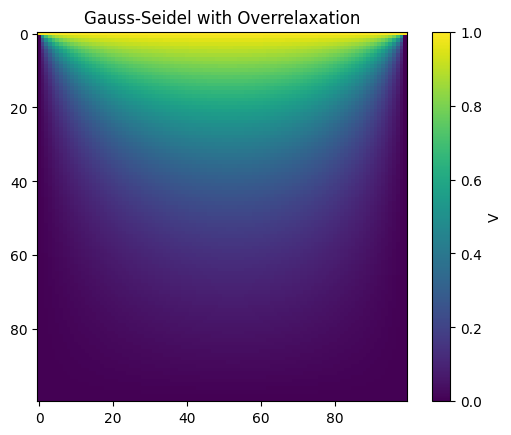

In [1]:
"""
@author: cbute

Program: ex9.2_gauss_seidel_with_overrelaxation
Purpose: Practice using Gauss-Seidel method with overrelaxation
Does it work?: Yes
Other information:

    # code adapted from example 9.1
    # takes about 30 seconds, at target=1e-6
"""
import numpy as np
import matplotlib.pyplot as plt
import sys

def phi(i,j,V):
    omega  = 0.9
    return (1.0+omega)*(V[j, i+1]+V[j,i-1]+V[j+1,i]+V[j-1,i])/4 - omega*V[j,i]


# define boundary potentials
Vtop = 1.0 #volt
Vbottom = 0.0 #volt
Vleft = 0.0 #volt
Vright = 0.0 #volt

# define grid spacing
a = 1e-2 # m

# grid size, assume square
N = 100

# create array to hold potential, and initialize to 0
solution = np.zeros([N,N], float)

# place boundary values in phi array
# careful values do not overwrite one another.
solution[N-1,:] = Vbottom
solution[:,0] = Vleft
solution[:,N-1] = Vright
solution[0,:] = Vtop

# set error target
epsilon = 1e-3 # volt

# create logical convergence variable
converge = False

it = 0 # iteration counter
while converge == False:
    it += 1
    converge = True
    # calculate new solutions just on the interior points
    for j in range(1,N-1):
        for i in range(1,N-1):
            store = solution[j,i]
            solution[j,i] = phi(i,j,solution) # use the old solutions to calculate new solutions
            if abs(solution[j,i]-store) > epsilon:
                converge = False

print ("Solution converged in {} iterations".format(it))
plt.imshow(solution)
plt.title("Gauss-Seidel with Overrelaxation")
plt.colorbar(label="V")
plt.show()

**Pts /10**

**b)** Repeat the problem, but now using the **Gauss-Seidel method with overrelaxation**. Compare the number of iterations it takes to converge with the number of iterations from the Jacobi method in part a.

In [ ]:
#Type your code here

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define grid parameters
N = 100  # Grid size
epsilon = 1e-6 # Convergence target in volts
omega = 1.8 # Overrelaxation factor (typically between 1 and 2)

# Initialize potential array with zeros
V_gs = np.zeros([N, N], float)

# Capacitor plate dimensions and positions (same as part a)
plate_width_start = N // 3
plate_width_end = 2 * N // 3
top_plate_row_center = N // 4
bottom_plate_row_center = 3 * N // 4
plate_thickness = 1 # Number of rows for plate thickness

# Set capacitor plate voltages
# Top plate (+1V)
V_gs[top_plate_row_center - plate_thickness:top_plate_row_center + plate_thickness + 1, plate_width_start:plate_width_end] = 1.0
# Bottom plate (-1V)
V_gs[bottom_plate_row_center - plate_thickness:bottom_plate_row_center + plate_thickness + 1, plate_width_start:plate_width_end] = -1.0

# Create a mask for fixed points (boundary and capacitor plates)
# These points will not be updated during iteration
fixed_points_gs = np.zeros([N, N], bool)
fixed_points_gs[0, :] = True  # Top wall
fixed_points_gs[N - 1, :] = True  # Bottom wall
fixed_points_gs[:, 0] = True  # Left wall
fixed_points_gs[:, N - 1] = True  # Right wall
fixed_points_gs[top_plate_row_center - plate_thickness:top_plate_row_center + plate_thickness + 1, plate_width_start:plate_width_end] = True
fixed_points_gs[bottom_plate_row_center - plate_thickness:bottom_plate_row_center + plate_thickness + 1, plate_width_start:plate_width_end] = True

# Gauss-Seidel with Overrelaxation iteration
converged_gs = False
it_gs = 0
max_iterations_gs = 100000 # Safety break

while not converged_gs and it_gs < max_iterations_gs:
    it_gs += 1
    converged_gs = True

    for j in range(1, N - 1):  # Rows
        for i in range(1, N - 1):  # Columns
            if not fixed_points_gs[j, i]: # Only update non-fixed points
                old_val = V_gs[j, i]
                # Gauss-Seidel update rule
                new_val_gs = 0.25 * (V_gs[j, i + 1] + V_gs[j, i - 1] + V_gs[j + 1, i] + V_gs[j - 1, i])
                # Overrelaxation step
                V_gs[j, i] = old_val + omega * (new_val_gs - old_val)

                if abs(V_gs[j, i] - old_val) > epsilon:
                    converged_gs = False

print(f"Solution converged in {it_gs} iterations with Gauss-Seidel (overrelaxation, omega={omega}).")
print(f"Jacobi method converged in 2817 iterations.")

# Plotting the result
plt.figure(figsize=(8, 7))
plt.imshow(V_gs, origin='lower', cmap='viridis', extent=[0, N, 0, N])
plt.colorbar(label='Potential (V)')
plt.title('Electrostatic Potential (Gauss-Seidel with Overrelaxation)')
plt.xlabel('Grid X')
plt.ylabel('Grid Y')
plt.show()


**Pts /5**

#### Exercise 1 Pts /15

## 2. Thermal diffusion in the Earth's crust : FTCS method

A classic example of a diffusion problem with a time-varying boundary condition is the diffusion of heat into the crust of the Earth, as surface temperature varies with the seasons.  Suppose the mean daily temperature at a particular point on the surface varies as:

\begin{equation*}
T_0(t) = A + B\sin {2\pi t\over\tau},
\end{equation*}

where $\tau=365\,$days, $A=10^\circ$C and $B=12^\circ$C.  At a depth of $20\,$m below the surface almost all annual temperature variation is ironed out and the temperature is, to a good approximation, a constant $11^\circ$C
(which is higher than the mean surface temperature of $10^\circ$C---temperature increases with depth, due to heating from the hot core of the planet).  The thermal diffusivity of the Earth's crust varies somewhat from place to place, but for our purposes we will treat it as constant with value $D=0.1\,\mathrm{m}^2\,\mathrm{day}^{-1}$.

Assume you calculate the temperature profile of the crust as a function of depth up to $20\,$m and time up to 10 years using the **FTCS method**.  

**a)** To use the FTCS method you have choose the number of spatial grid points M, and the number of time steps N. Show that your choices of M and N meet the condition of numerical stability.

**Type your response here**


**Pts /5**

**b)** Now write a program to calculate the temperature profile of the crust as a function of depth up to $20\,$m and time up to 10 years using the **FTCS method**.  Start with temperature everywhere equal to $10^\circ$C, except at the surface and the deepest point, choose values for the number of grid points and the time-step $h$, then run your program
for the first nine simulated years, to allow it to settle down into whatever pattern it reaches.  Then for the tenth and final year plot four temperature profiles taken at 3-month intervals on a single graph to illustrate the seasonal temperature profiles.

In [ ]:
## Type your code here

**Pts /10**

#### Exercise 2 Pts /15

## Total HW Pts /30